In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import pandas as pd
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

# Allow more columns to be displayed
pd.set_option("display.max_columns", None)

import logging
logging.basicConfig(level=logging.WARNING)

In [4]:
!which python

/Users/klemenkubelj/miniconda3/envs/cvar-masters/bin/python


In [5]:
df = pd.read_csv(os.path.join("../data/vloge_processed_2025-05-10.csv"))
print("Original shape:", df.shape)

# Show number of samples, split by event
event_sample_counts = df["DogodekId"].value_counts()
print("Number of samples split by event:")
print(event_sample_counts)

# df["relative_damage"] = df["SkupnaSkoda"] / df["Vrednost"]
df["relative_damage"] = df["OdstPoskodovanostiObjekta"] / 100
df["Objekt_VisinaVodeM"] = df["Objekt_VisinaVodeCm"] / 100
df = df[df["relative_damage"]<=1]
print("After filtering:", df.shape)

Original shape: (20040, 18)
Number of samples split by event:
DogodekId
68    12389
14     3086
18     2415
24     2150
Name: count, dtype: int64
After filtering: (6440, 20)


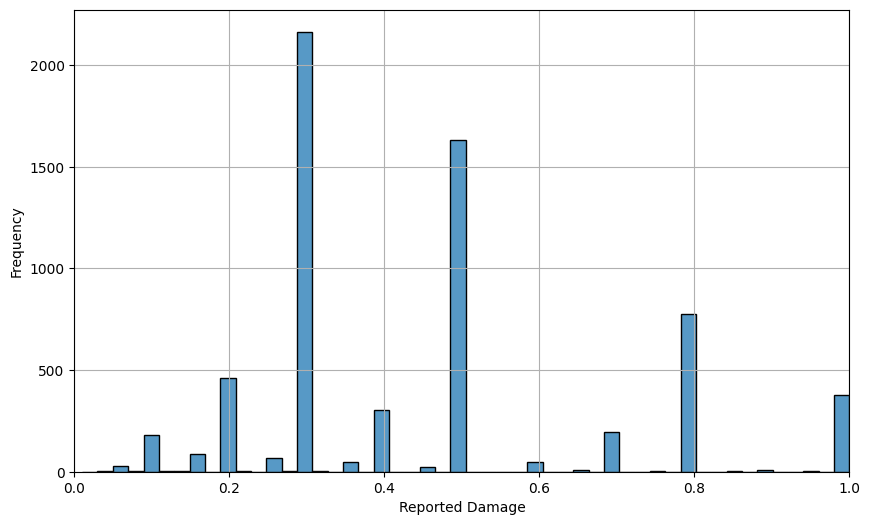

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df["relative_damage"], bins=50)
# plt.title("Histogram of Relative Damage")
plt.xlabel("Reported Damage")
plt.ylabel("Frequency")
plt.grid(True)
plt.xlim(0,1)
plt.show()


In [7]:
df.head()

,VlogaId,Objekt_Naslov,Objekt_Naslov_PostnaStevilka,Objekt_Parcela_Stevilka,Objekt_Parcela_KoId,Objekt_UporabnaPovrsina,Objekt_VisinaVodeCm,Objekt_StopnjaPoskodovanosti,Objekt_CentroidX,Objekt_CentroidY,Skoda_DatumOcene,Objekt_SkodaPovzrocenaVPlazu,Objekt_VrstaObjektaId,DogodekId,Vrednost,OdstPoskodovanostiObjekta,SkupnaSkoda,SkupnaSkodaSource,relative_damage,Objekt_VisinaVodeM
206,149162,Čužnja vas 12,8231 TREBELNO,2501/3,1449,35.00,0.0,NaN,515501.0,85416.0,10/15/10 00:00:00,NaN,2.0,14,3309.35,100.0,3309.35,Postavka3,1.0,0.0
788,155809,Poklek nad Blanco 10,8283 BLANCA,172/0.S,2307,214.54,0.0,NaN,530288.0,97018.0,10/21/10 00:00:00,NaN,2.0,14,72396.27,100.0,72396.27,Postavka3,1.0,0.0
1296,152700,Vrh nad Laškim 3,3270 LAŠKO,187/0.S,1705,161.65,40.0,NaN,521876.0,109619.0,09/28/10 00:00:00,NaN,2.0,14,54338.48,100.0,54338.48,Postavka3,1.0,0.4
1298,157182,Obrežje pri Zidanem Mostu 50,1432 ZIDANI MOST,576/2,1625,196.41,0.0,NaN,513876.0,104422.0,11/04/10 00:00:00,NaN,2.0,14,61876.97,70.0,43313.88,Postavka3,0.7,0.0
1299,157304,Obrežje pri Zidanem Mostu 49,1432 ZIDANI MOST,22/8.S,1625,57.75,0.0,NaN,513884.0,104450.0,11/04/10 00:00:00,NaN,2.0,14,14169.51,100.0,14169.51,Postavka3,1.0,0.0


In [8]:
# Show number of samples, split by event
event_sample_counts = df["DogodekId"].value_counts()
print("Number of samples split by event:")
print(event_sample_counts)

Number of samples split by event:
DogodekId
68    6389
18      32
14      16
24       3
Name: count, dtype: int64


(0.0, 300.0)

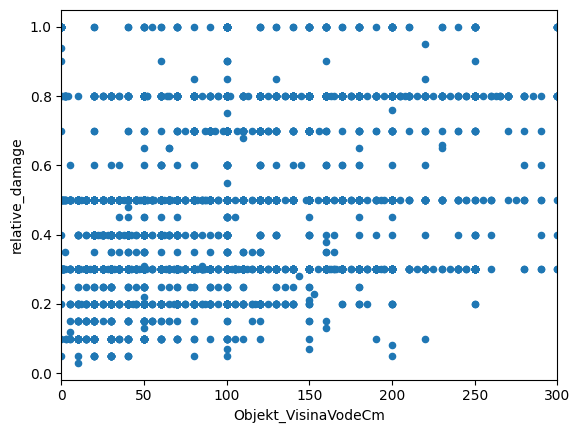

In [9]:

df.plot(x="Objekt_VisinaVodeCm", y="relative_damage", kind="scatter")
plt.xlim(0, 300)

In [10]:
residential_damage_fractions = [
    (0, 0.00),
    (0.5, 0.25),
    (1, 0.40),
    (1.5, 0.50),
    (2, 0.60),
    (2.5, 0.675),
]
commercial_damage_function = [
    (0, 0.00),
    (0.5, 0.15),
    (1, 0.30),
    (1.5, 0.45),
    (2, 0.55),
    (2.5, 0.675),
]
industrial_damage_function = [
    (0, 0.00),
    (0.5, 0.15),
    (1, 0.27),
    (1.5, 0.40),
    (2, 0.52),
    (2.5, 0.675),
]
agriculture_damage_function = [
    (0, 0.00), 
    (0.5, 0.30), 
    (1, 0.55), 
    (1.5, 0.65), 
    (2, 0.75), 
    (2.5, 0.80),
]
def plot_violin_damage_by_water_height(df, title: str = ""):
    _df = df.copy()
    total_samples = len(_df)

    # Create water height buckets (every 50cm up to 200cm)
    bucket_edges = np.arange(0, 2.01, 0.5)
    _df["water_height_bucket"] = pd.cut(
        _df["Objekt_VisinaVodeM"], 
        bins=bucket_edges,
        labels=[f"{i}-{i+0.5}m" for i in np.arange(0, 2, 0.5)]
    )

    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot violins
    sns.violinplot(
        data=_df,
        x="water_height_bucket",
        y="relative_damage",
        cut=0,  # limit the violin plot to actual data range
        ax=ax  # specify the axis to plot on
    )

    # Adjust x-axis to show ticks at the upper bounds of each bucket
    ax.set_xticks(range(len(bucket_edges)-1))
    ax.set_xticklabels([f"{x}m" for x in bucket_edges[1:]])

    # Set y-axis range from 0 to 1
    ax.set_ylim(0, 1)

    # Add count and median annotations for each bucket
    # Calculate and plot median values
    medians = _df.groupby("water_height_bucket", observed=False)["relative_damage"].median()
    for i, median in enumerate(medians):
        # Add horizontal line for median
        ax.hlines(median, i-0.2, i+0.2, colors="red", linestyles="--", alpha=0.7)

    bucket_counts = _df["water_height_bucket"].value_counts().sort_index()
    for i, (count, median) in enumerate(zip(bucket_counts, medians)):
        ax.text(i, ax.get_ylim()[0], f"n={count}\nmed={median:.2f}", 
                ha="center", va="bottom", 
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

    # Customize the plot
    ctitle = f"Distribution of Relative Damage by Water Height (Total Samples: {total_samples})"
    if title:
        ctitle += f" - {title}"
    ax.set_title(ctitle)
    ax.set_xlabel("Water Height")
    ax.set_ylabel("Relative Damage")
    ax.tick_params(axis="x", rotation=45)

    # Add grid for better readability
    ax.grid(True, axis="y", linestyle="--", alpha=0.7)
    fig.tight_layout()
    
    return fig, ax

def plot_damage_function(damage_function, color="orange", label="NONE"):
    fig = plt.gcf()
    ax = plt.gca()

    flood_depths = [i[0] for i in damage_function]
    damage_fractions = [i[1] for i in damage_function]

    def get_damage_fraction(depth):
        """
        Get damage fraction for a given flood depth using polynomial interpolation.
        For depths outside the range, we clamp the values to [0, 1].
        
        Args:
            depth (float): Flood depth in meters
            
        Returns:
            float: Damage fraction between 0 and 1
        """
        # Create interpolation function
        f = interp1d(flood_depths, damage_fractions, kind="linear", bounds_error=False, fill_value=(0, 1))
        return float(f(depth))

    # Create points for smooth curve visualization
    depths_smooth = np.linspace(0, max(flood_depths), 100)
    damage_smooth = [get_damage_fraction(d) for d in depths_smooth]

    # Plot the data and fitted curve
    ax.plot([(i - 0.5)*2 for i in flood_depths], damage_fractions, "o", color=color)
    # Dont show this in legend
    ax.plot([(i - 0.5)*2 for i in depths_smooth], damage_smooth, "-", label=label, color=color)
    
    # Set y-axis range from 0 to 1
    # ax.set_ylim(0, 1)
    
    # Add labels and title
    # ax.set_xlabel("Water Height (m)")
    # ax.set_ylabel("Damage Fraction")
    # ax.set_title("Damage Function")
    # ax.grid(True, linestyle="--", alpha=0.7)
    
    
    # Return the figure and axis for further customization
    return fig, ax

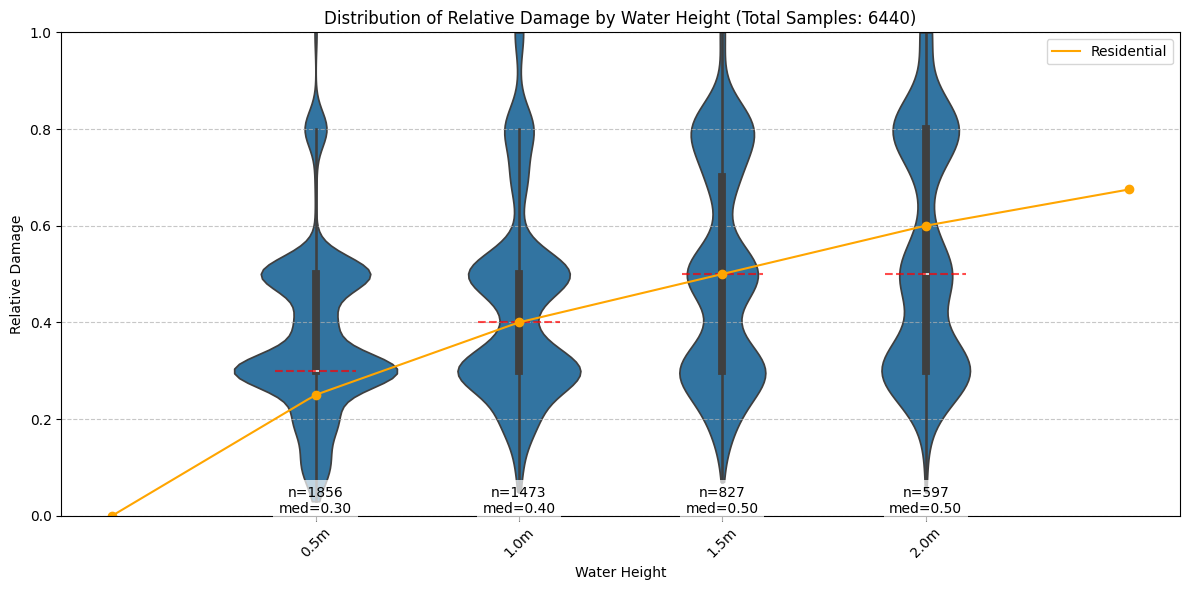

In [11]:
_df = df.copy()
# _df = _df[_df["Objekt_VrstaObjektaId"].isin([1, 2, 4, 5])]
fig, ax = plot_violin_damage_by_water_height(_df)
fig, ax = plot_damage_function(residential_damage_fractions, color="orange", label="Residential")
# fig, ax = plot_damage_function(commercial_damage_function, color="red", label="Commercial")
# fig, ax = plot_damage_function(industrial_damage_function, color="purple", label="Industrial")
# fig, ax = plot_damage_function(agriculture_damage_function, color="green", label="Agriculture")
ax.legend()

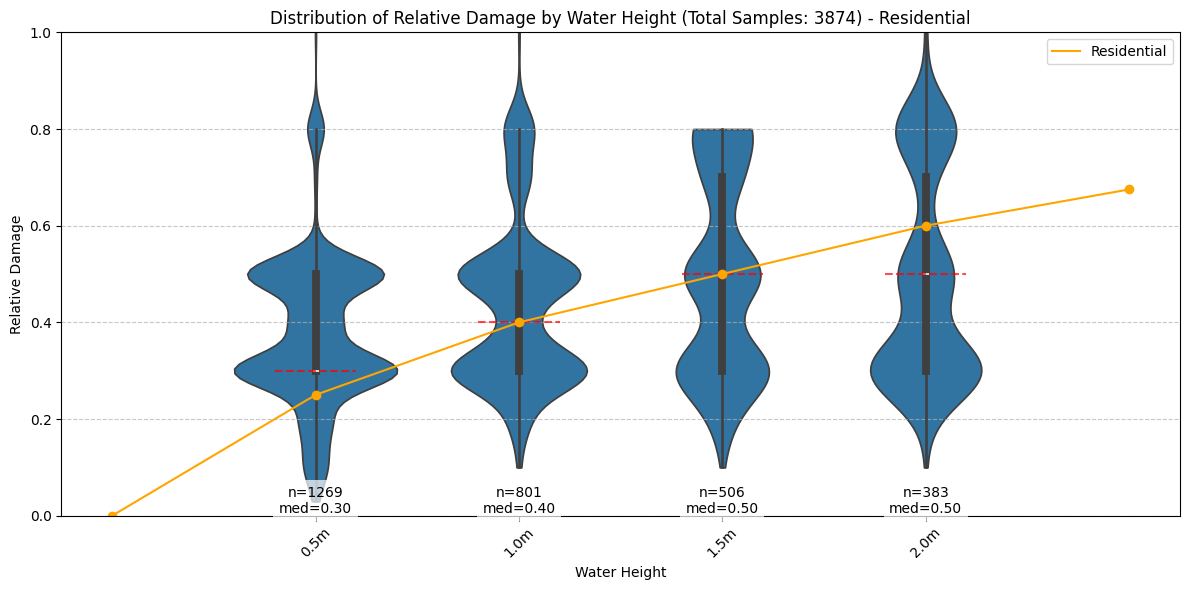

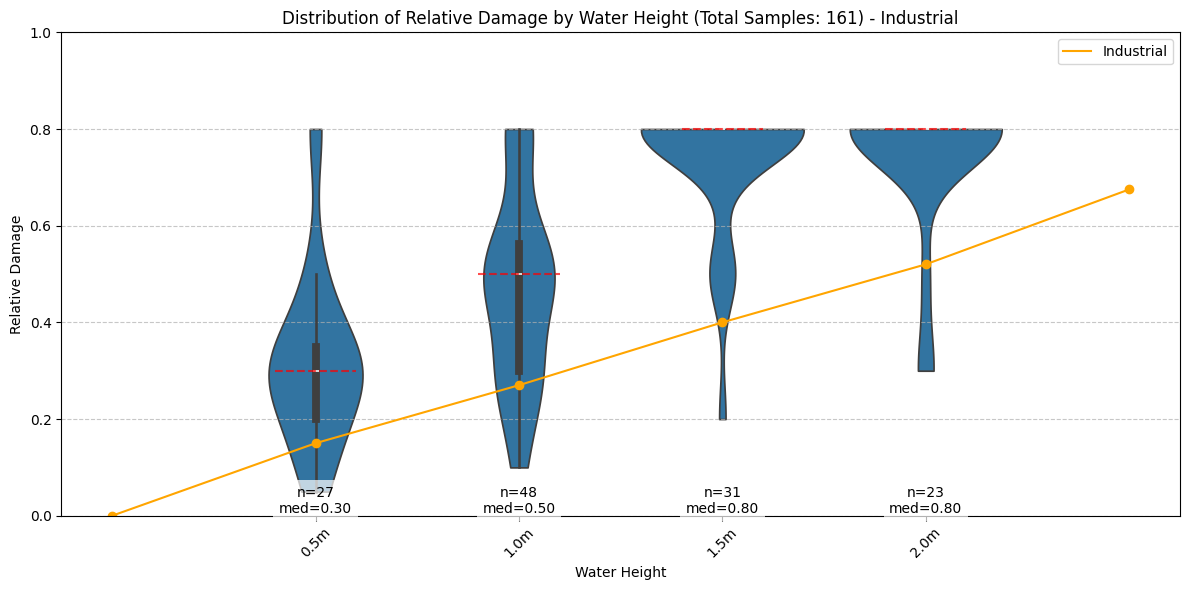

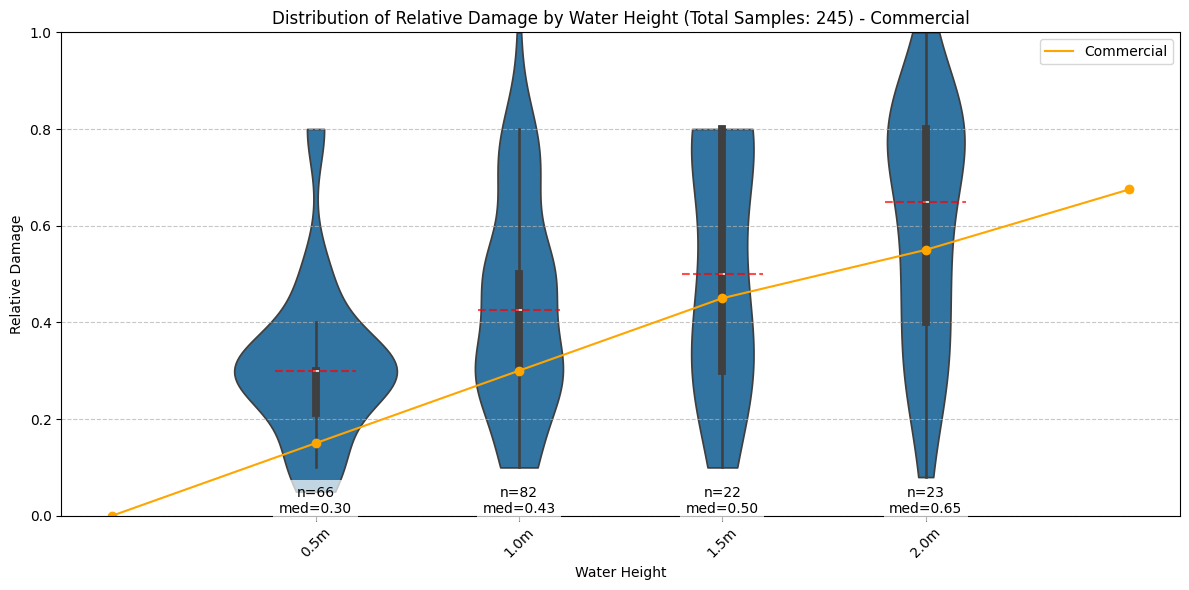

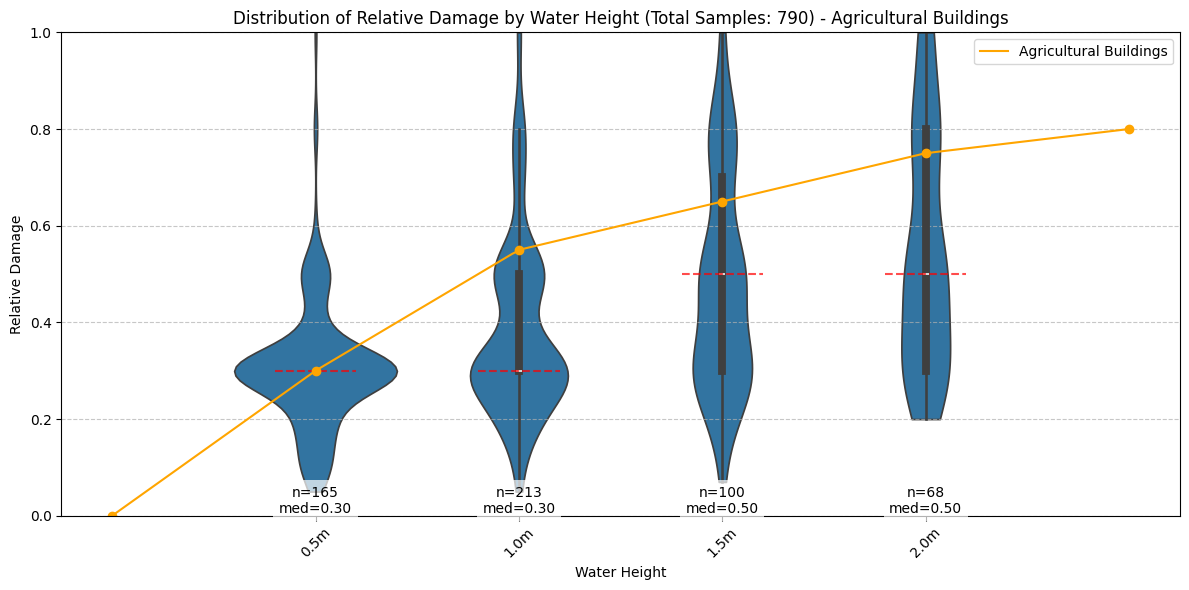

In [12]:

for vrste_objekta_id, title, damage_function in [
    ((2,), "Residential", residential_damage_fractions),
    ((1,), "Industrial", industrial_damage_function),
    ((4,), "Commercial", commercial_damage_function),
    ((5,), "Agricultural Buildings", agriculture_damage_function),
]:  
    _df = df.copy()
    _df = _df[_df["Objekt_VrstaObjektaId"].isin(vrste_objekta_id)]
    # plot_violin_damage_by_water_height(_df)
    fig, ax = plot_violin_damage_by_water_height(_df, title=title)
    fig, ax = plot_damage_function(damage_function, color="orange", label=title)
    ax.legend()

# Statistics & Graphs

In [13]:
residential_damage_fractions = [
    (0, 0.00),
    (0.5, 0.25),
    (1, 0.40),
    (1.5, 0.50),
    (2, 0.60),
    (3, 0.75),
    (4, 0.85),
    (5, 0.95),
    (6, 1.00),
]
commercial_damage_function = [
    (0, 0.00),
    (0.5, 0.15),
    (1, 0.30),
    (1.5, 0.45),
    (2, 0.55),
    (3, 0.75),
    (4, 0.90),
    (5, 1.00),
    (6, 1.00),
]
industrial_damage_function = [
    (0, 0.00),
    (0.5, 0.15),
    (1, 0.27),
    (1.5, 0.40),
    (2, 0.52),
    (3, 0.70),
    (4, 0.85),
    (5, 1.00),
    (6, 1.00),
]
agriculture_damage_function = [
    (0, 0.00),
    (0.5, 0.30),
    (1, 0.55),
    (1.5, 0.65),
    (2, 0.75),
    (3, 0.85),
    (4, 0.95),
    (5, 1.00),
    (6, 1.00),
]



In [14]:

def plot_damage_function_full_range(damage_function, color="orange", label="NONE"):
    fig = plt.gcf()
    ax = plt.gca()

    flood_depths = [i[0] for i in damage_function]
    damage_fractions = [i[1] for i in damage_function]

    def get_damage_fraction(depth):
        """
        Get damage fraction for a given flood depth using polynomial interpolation.
        For depths outside the range, we clamp the values to [0, 1].
        
        Args:
            depth (float): Flood depth in meters
            
        Returns:
            float: Damage fraction between 0 and 1
        """
        # Create interpolation function
        f = interp1d(flood_depths, damage_fractions, kind="linear", bounds_error=False, fill_value=(0, 1))
        return float(f(depth))

    # Create points for smooth curve visualization
    depths_smooth = np.linspace(0, max(flood_depths), 100)
    damage_smooth = [get_damage_fraction(d) for d in depths_smooth]

    # Plot the data and fitted curve
    ax.plot(flood_depths, damage_fractions, "o", color=color)
    # Dont show this in legend
    ax.plot(depths_smooth, damage_smooth, "-", label=label, color=color)
    
    # Set y-axis range from 0 to 1
    # ax.set_ylim(0, 1)
    
    # Add labels and title
    ax.set_xlabel("Flood Depth [m]")
    ax.set_ylabel("Damage")
    # ax.set_title("Damage Function")
    ax.grid(True, linestyle="--", alpha=0.7)
    
    
    # Return the figure and axis for further customization
    return fig, ax

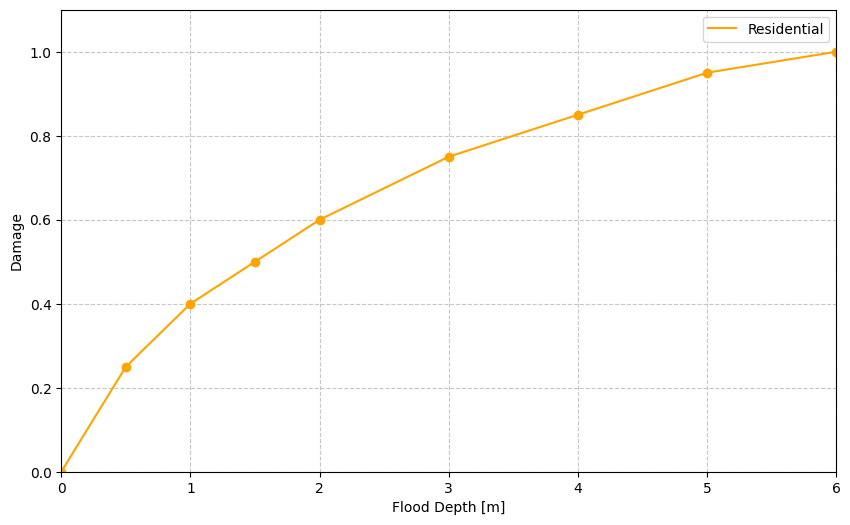

In [15]:
plot_damage_function_full_range(residential_damage_fractions, color="orange", label="Residential")
# plot_damage_function_full_range(commercial_damage_function, color="red", label="Commercial")
# plot_damage_function_full_range(industrial_damage_function, color="purple", label="Industrial")
# plot_damage_function_full_range(agriculture_damage_function, color="green", label="Agriculture")
# plt.grid()
# plt.title("Flood Depth-Damage Function (Europe)")

plt.xlim(0, 6)
plt.ylim(0, 1.1)
plt.legend()

# Make wider
plt.gcf().set_size_inches(10, 6)


In [16]:
from utils.flood_request_utils import (
    get_wri_and_si_hazard_data,
    plot_wri_and_si_hazard_data,
    get_damage_fraction,
    plot_wri_and_si_vulnerability_data,
)

In [17]:
litija_1 = {
    "lng": 14.836790,
    "lat": 46.060307
}
litija_2 = {
    "lng": 14.821837,
    "lat": 46.056977
}

In [18]:
data, request = get_wri_and_si_hazard_data(litija_2)
fig = plot_wri_and_si_hazard_data(data, request)#, x_axis="AEP")
fig.show()

index_values:  [2.0, 5.0, 10.0, 25.0, 50.0, 100.0, 250.0, 500.0, 1000.0]
intensities:  [0.02401801198720932, 0.10212962329387665, 0.1537131667137146, 0.21867892146110535, 0.2668743133544922, 0.3147137761116028, 0.37761956453323364, 0.4250403046607971, 0.4723888039588928]
index_values:  [10.0, 100.0, 500.0]
intensities:  [0.0, 0.0, 1.5]
index_values:  [100.0]
intensities:  [0.0]


In [19]:
fig = plot_wri_and_si_hazard_data(data, request, x_axis="AEP")
fig.show()

index_values:  [0.5, 0.2, 0.1, 0.04, 0.02, 0.01, 0.004, 0.002, 0.001]
intensities:  [0.02401801198720932, 0.10212962329387665, 0.1537131667137146, 0.21867892146110535, 0.2668743133544922, 0.3147137761116028, 0.37761956453323364, 0.4250403046607971, 0.4723888039588928]
index_values:  [0.1, 0.01, 0.002]
intensities:  [0.0, 0.0, 1.5]
index_values:  [0.01]
intensities:  [0.0]


In [20]:
return_periods = data["items"][0]["intensity_curve_set"][0]["index_values"]
exceeded_probabilities = [1 / rp for rp in return_periods]
depths = data["items"][0]["intensity_curve_set"][0]["intensities"]
damage_fractions = [get_damage_fraction(depth) for depth in depths]

value = 100000 # 100k EUR
damage_total = [value * df for df in damage_fractions]


print("return_periods: ", return_periods)
print("exceeded_probabilities: ", exceeded_probabilities)

print("depths: ", depths)
print("damage_fractions: ", damage_fractions)
print("damage_total: ", damage_total)

return_periods:  [2.0, 5.0, 10.0, 25.0, 50.0, 100.0, 250.0, 500.0, 1000.0]
exceeded_probabilities:  [0.5, 0.2, 0.1, 0.04, 0.02, 0.01, 0.004, 0.002, 0.001]
depths:  [0.02401801198720932, 0.10212962329387665, 0.1537131667137146, 0.21867892146110535, 0.2668743133544922, 0.3147137761116028, 0.37761956453323364, 0.4250403046607971, 0.4723888039588928]
damage_fractions:  [0.01200900599360466, 0.051064811646938324, 0.0768565833568573, 0.10933946073055267, 0.1334371566772461, 0.1573568880558014, 0.18880978226661682, 0.21252015233039856, 0.2361944019794464]
damage_total:  [1200.900599360466, 5106.481164693832, 7685.65833568573, 10933.946073055267, 13343.71566772461, 15735.68880558014, 18880.978226661682, 21252.015233039856, 23619.44019794464]


In [21]:
def bplot(x, y, xlabel, ylabel, logx: bool = False, color="c"):
    plt.plot(x, y, "o", color=color)
    plt.plot(x, y, color=color)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if logx:
        plt.xscale("log")

    # Add grid lines for both x and y axes
    plt.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.grid(True, axis="x", which="both",  linestyle="--", alpha=0.5)
    plt.tight_layout()

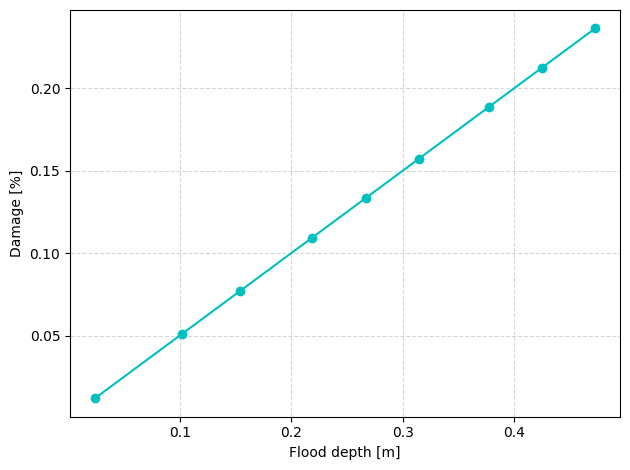

In [22]:
bplot(depths, damage_fractions, "Flood depth [m]", "Damage [%]")

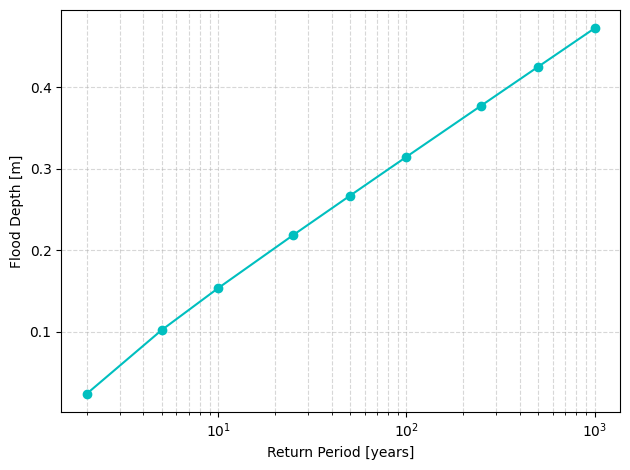

In [23]:
bplot(return_periods, depths, "Return Period [years]", "Flood Depth [m]", logx=True)

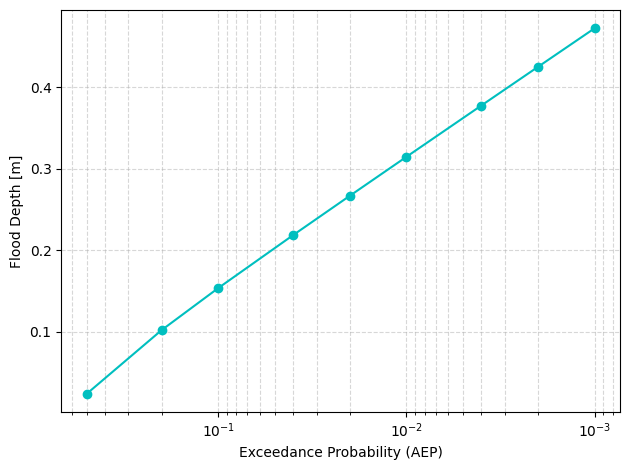

In [24]:
bplot(exceeded_probabilities, depths, "Exceedance Probability (AEP)", "Flood Depth [m]", logx=True)
plt.gca().invert_xaxis()

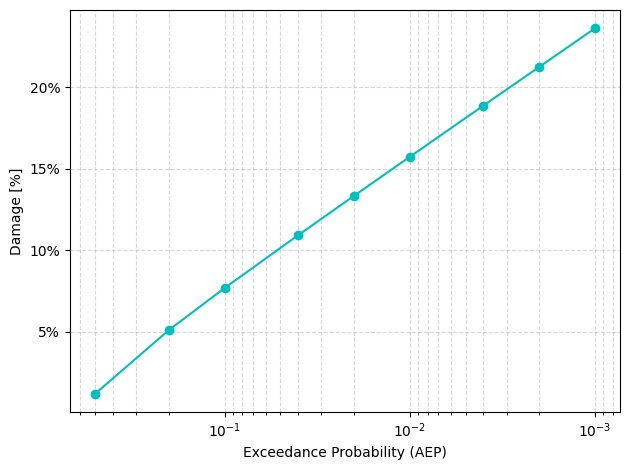

In [25]:
bplot(exceeded_probabilities, damage_fractions, "Exceedance Probability (AEP)", "Damage [%]", logx=True)
# Set y to % (whole number) instead of decimal
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.gca().invert_xaxis()

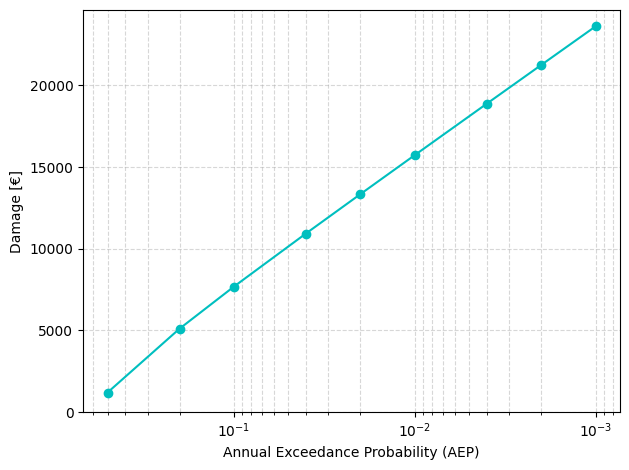

In [26]:
bplot(exceeded_probabilities, damage_total, "Annual Exceedance Probability (AEP)", "Damage [€]", logx=True)
plt.ylim(0, max(damage_total)+1000)
plt.gca().invert_xaxis()

Text(0.7, 0.1, 'EAD: 2699 €')

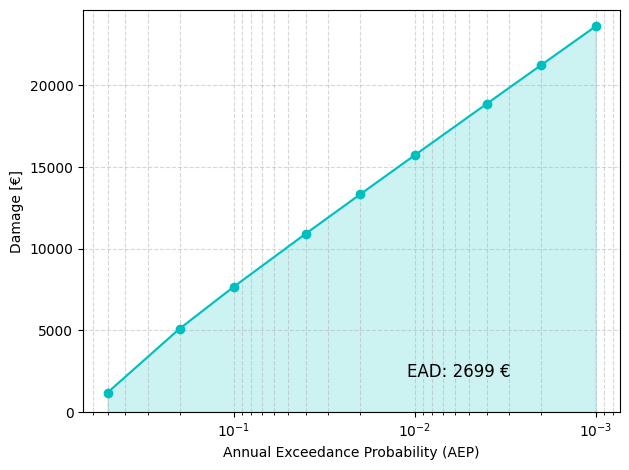

In [27]:
bplot(exceeded_probabilities, damage_total, "Annual Exceedance Probability (AEP)", "Damage [€]", logx=True)
plt.ylim(0, max(damage_total)+1000)
plt.gca().invert_xaxis()

# Calculate and display the area under the curve
area_under_curve = abs(np.trapz(damage_total, x=exceeded_probabilities))
plt.fill_between(exceeded_probabilities, damage_total, alpha=0.2, color="c")
plt.text(0.7, 0.1, f"EAD: {area_under_curve:.0f} €", transform=plt.gca().transAxes, fontsize=12, verticalalignment='center', horizontalalignment='center')

Text(0.7, 0.1, 'EAD: 2699 €')

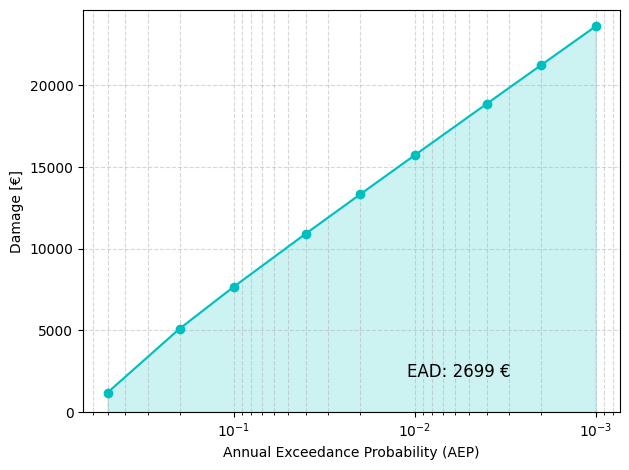

In [36]:
bplot(exceeded_probabilities, damage_total, "Annual Exceedance Probability (AEP)", "Damage [€]", logx=True)
plt.ylim(0, max(damage_total)+1000)
plt.gca().invert_xaxis()

# Calculate and display the area under the curve
area_under_curve = abs(np.trapz(damage_total, x=exceeded_probabilities))
plt.fill_between(exceeded_probabilities, damage_total, alpha=0.2, color="c")
plt.text(0.7, 0.1, f"EAD: {area_under_curve:.0f} €", transform=plt.gca().transAxes, fontsize=12, verticalalignment='center', horizontalalignment='center')

In [32]:
exceeded_probabilities + [10**-4,]

[0.5, 0.2, 0.1, 0.04, 0.02, 0.01, 0.004, 0.002, 0.001, 0.0001]

In [34]:
damage_total + [30619]

[1200.900599360466,
 5106.481164693832,
 7685.65833568573,
 10933.946073055267,
 13343.71566772461,
 15735.68880558014,
 18880.978226661682,
 21252.015233039856,
 23619.44019794464,
 30619]

Text(0.7, 0.1, 'EAD: 2723.30 €')

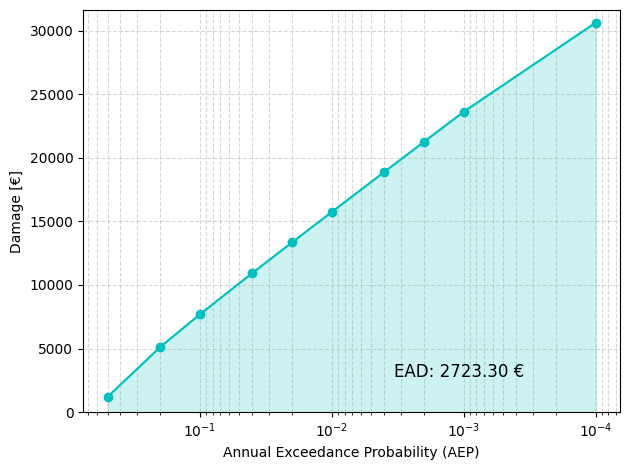

In [35]:
x = exceeded_probabilities + [10**-4,]
y = damage_total + [30619]
bplot(x, y, "Annual Exceedance Probability (AEP)", "Damage [€]", logx=True)
plt.ylim(0, max(y)+1000)
plt.gca().invert_xaxis()

# Calculate and display the area under the curve
area_under_curve = abs(np.trapz(y, x=x))
plt.fill_between(x, y, alpha=0.2, color="c")
plt.text(0.7, 0.1, f"EAD: {area_under_curve:.2f} €", transform=plt.gca().transAxes, fontsize=12, verticalalignment='center', horizontalalignment='center')